## Which Stats Contribute Most To Winning Matches

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
from pandasql import sqldf
import sqlite3 
import datetime as dt
import plotly.express as px

In [17]:
con = sqlite3.connect('/Users/julianbombard/Desktop/Data Analytics Course/Capstone/database/ATP_Tour')
df = pd.read_sql_query('''Select *
                       From cleaned_match_stats''', con)

con.close()

df.head()

,player_id,match_id,year,month,player_name,country,height,hand,tourney_name,tourney_level,...,bp_saved,bp_faced,rank,rank_points,won,first_sv_pct,first_sv_win_pct,second_sv_win_pct,total_sv_win_pct,bp_save_pct
0,105357,2015-339_1,2015,1,John Millman,AUS,183,R,Brisbane,A,...,1,1,153,328,1,0.545455,0.791667,0.700000,0.750000,1.000000
1,103813,2015-339_2,2015,1,Jarkko Nieminen,FIN,185,L,Brisbane,A,...,4,7,73,689,1,0.641304,0.661017,0.515152,0.608696,0.571429
2,105902,2015-339_3,2015,1,James Duckworth,AUS,183,R,Brisbane,A,...,2,3,125,430,1,0.600000,0.740741,0.611111,0.688889,0.666667
3,104871,2015-339_4,2015,1,Jeremy Chardy,FRA,188,R,Brisbane,A,...,0,0,31,1195,1,0.735849,0.794872,0.785714,0.792453,NaN
4,105373,2015-339_5,2015,1,Martin Klizan,SVK,191,L,Brisbane,A,...,6,8,34,1094,1,0.607692,0.696203,0.529412,0.630769,0.750000


In [18]:
df['won'] = df['won'].astype('bool')

In [19]:
df['ace_pct'] = (df['ace'] / df['svpt'])

## Correlations

In [20]:
stat_columns = df.select_dtypes(include = [np.number, 'bool'])

correlations = stat_columns.corr()['won'].drop(['won', 'month', 'year']).sort_values(ascending = False)
print(correlations)

total_sv_win_pct     0.611462
first_sv_win_pct     0.509953
second_sv_win_pct    0.462707
bp_save_pct          0.299219
ace_pct              0.237578
rank_points          0.198847
ace                  0.158791
first_won            0.135203
first_sv_pct         0.119937
second_won           0.110232
height               0.064227
sv_gms               0.027185
player_id            0.009595
minutes             -0.000975
first_in            -0.015436
svpt                -0.051525
df                  -0.133026
rank                -0.152069
bp_saved            -0.203976
bp_faced            -0.394425
Name: won, dtype: float64


In [21]:
correlation_df = pd.DataFrame(correlations)
correlation_df.to_csv('../csvs/correlations.csv')

## T- Tests

In [22]:
winners = df[df['won'] == True]
losers = df[df['won'] == False]

In [23]:
test_stats = stat_columns.columns.tolist()

In [24]:
for i in test_stats:
    winners = winners.dropna()
    losers = losers.dropna()
    stat, p_value = stats.ttest_ind(
        winners[i],
        losers[i],
        equal_var = False
    )
    print(f"{i:15} | p = {p_value:.4f}")
   



player_id       | p = 0.0228
year            | p = 0.9498
month           | p = 0.5493
height          | p = 0.0000
minutes         | p = 0.0000
ace             | p = 0.0000
df              | p = 0.0000
svpt            | p = 0.9312
first_in        | p = 0.0000
first_won       | p = 0.0000
second_won      | p = 0.0000
sv_gms          | p = 0.0000
bp_saved        | p = 0.0000
bp_faced        | p = 0.0000
rank            | p = 0.0000
rank_points     | p = 0.0000
won             | p = 0.0000
first_sv_pct    | p = 0.0000
first_sv_win_pct | p = 0.0000
second_sv_win_pct | p = 0.0000
total_sv_win_pct | p = 0.0000
bp_save_pct     | p = 0.0000
ace_pct         | p = 0.0000


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


it seems that basically ever statistic has extremely sigfnicant contribution towards winning  

## Box Plots

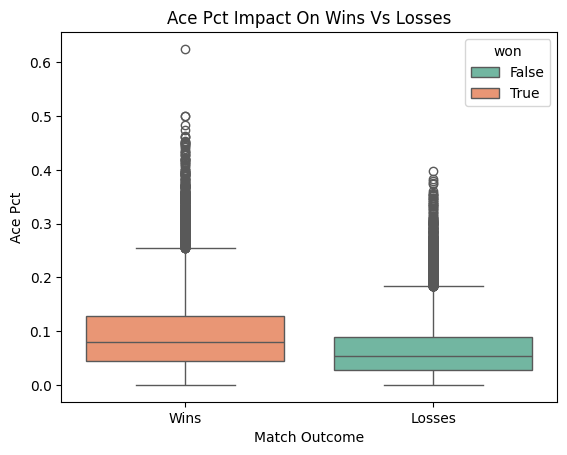

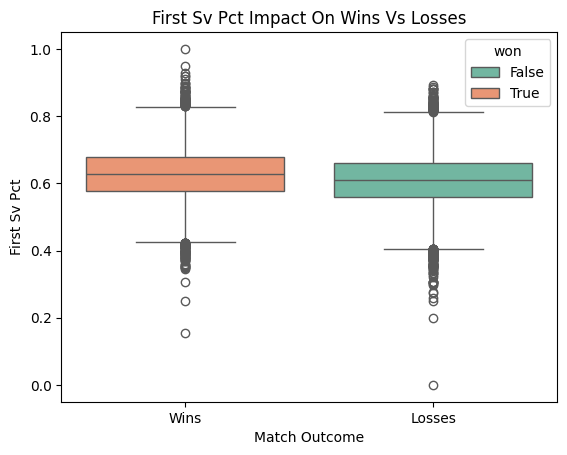

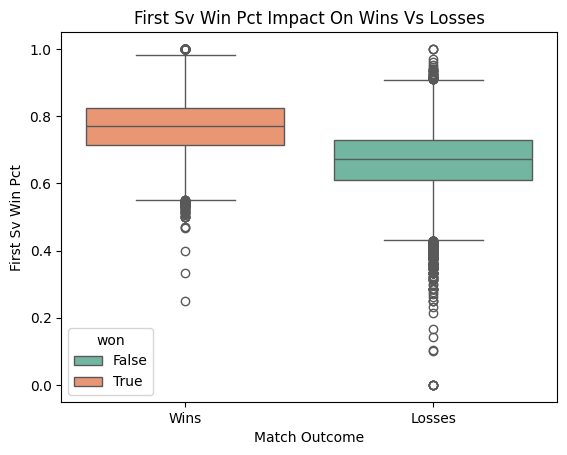

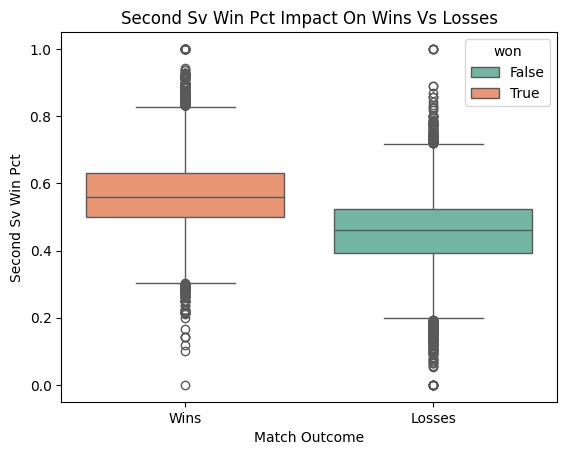

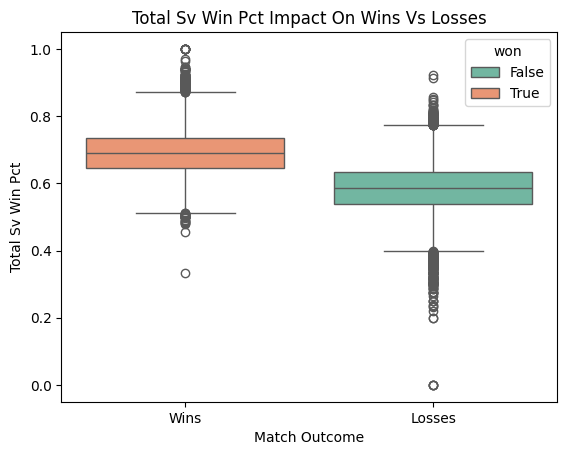

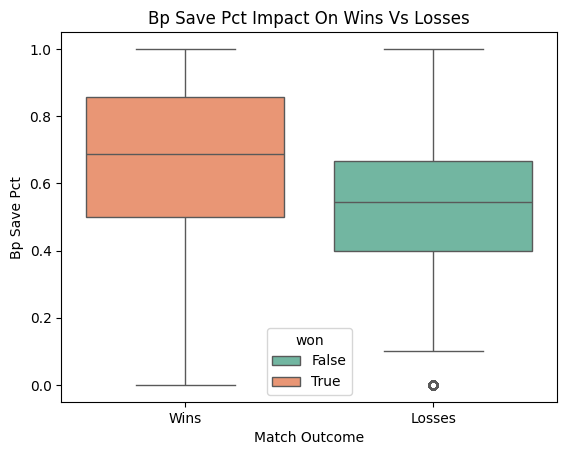

In [25]:
test_stats = ['ace_pct', 'first_sv_pct', 'first_sv_win_pct', 'second_sv_win_pct', 'total_sv_win_pct', 'bp_save_pct']

for i in test_stats:
    sns.boxplot(
        data = df, 
        x = df['won'].replace({True: 'Wins', False : 'Losses'}), 
        y = i, 
        hue = 'won', 
        palette = 'Set2')
    plt.title(f'{i.replace('_', ' ').title()} Impact On Wins Vs Losses')
    plt.xlabel('Match Outcome')
    plt.ylabel(i.replace('_', ' ').title())
    plt.show()

## Group By Player

In [26]:
players = df.groupby('player_name').agg(
    wins = ('won', 'sum'),
    total_matches = ('won', 'count'),
    ace_pct = ('ace_pct', 'mean'), 
    first_sv_pct = ('first_sv_pct', 'mean'),
    first_sv_win_pct = ('first_sv_win_pct', 'mean'),	
    second_sv_win_pct = ('second_sv_win_pct', 'mean'),	
    total_sv_win_pct = ('total_sv_win_pct', 'mean'),	
    bp_save_pct = ('bp_save_pct', 'mean'),
).reset_index()

players['win_pct'] = (players['wins'] / players['total_matches'])
players

,player_name,wins,total_matches,ace_pct,first_sv_pct,first_sv_win_pct,second_sv_win_pct,total_sv_win_pct,bp_save_pct,win_pct
0,Abedallah Shelbayh,3,14,0.060744,0.586241,0.668500,0.451588,0.576036,0.567509,0.214286
1,Adam Moundir,0,1,0.013514,0.513514,0.736842,0.500000,0.621622,0.600000,0.000000
2,Adam Neff,0,1,0.055556,0.569444,0.585366,0.387097,0.500000,0.636364,0.000000
3,Adam Pavlasek,5,14,0.078445,0.595819,0.684677,0.449941,0.590058,0.607515,0.357143
4,Adam Walton,3,13,0.073005,0.646830,0.734747,0.505810,0.652720,0.632613,0.230769
...,...,...,...,...,...,...,...,...,...,...
691,Ze Zhang,0,10,0.059814,0.639135,0.662396,0.413828,0.573442,0.564421,0.000000
692,Zhe Li,0,8,0.036640,0.646687,0.604653,0.487946,0.564120,0.396336,0.000000
693,Zhizhen Zhang,48,102,0.088001,0.638311,0.722401,0.519273,0.648518,0.540799,0.470588
694,Zizou Bergs,15,44,0.075466,0.631730,0.710247,0.508732,0.635471,0.590473,0.340909


Test correlations to win %

In [27]:
stat_columns = players.select_dtypes(include = [np.number])

correlations = stat_columns.corr()['win_pct'].drop(['wins', 'total_matches', 'win_pct' ]).sort_values(ascending = False)
print(correlations)

total_sv_win_pct     0.573839
first_sv_win_pct     0.491580
second_sv_win_pct    0.437669
bp_save_pct          0.374114
ace_pct              0.299618
first_sv_pct         0.153563
Name: win_pct, dtype: float64


ANOVA Test

In [28]:
low_win_pct = players[players['win_pct'] <= 0.4]
medium_win_pct = players[(players['win_pct'] > 0.4) & (players['win_pct'] <= 0.7)]
high_win_pct = players[players['win_pct'] > 0.7]

groups = [low_win_pct, medium_win_pct, high_win_pct]

test_stats = ['ace_pct', 'first_sv_pct', 'first_sv_win_pct', 'second_sv_win_pct', 'total_sv_win_pct', 'bp_save_pct']

results = {}

for i in test_stats:
    group_data = [group[i].dropna() for group in groups]
    f_stat, p_value = stats.f_oneway(*group_data)
    results[i] = {'f_stat' : f_stat, 'p_value' : p_value}

results_df = pd.DataFrame(results).T
print(results_df)

                      f_stat       p_value
ace_pct            24.792029  3.987567e-11
first_sv_pct        7.811244  4.418679e-04
first_sv_win_pct   64.392236  2.241004e-26
second_sv_win_pct  45.967190  1.796013e-19
total_sv_win_pct   94.915910  3.692721e-37
bp_save_pct        33.891278  9.063302e-15


Due to the extremely low p-values, we can conlude that all statistics are significantly different between players with differnt win percentages. Additionally, the high f_stat suggests that the variance between groups is much larger than the variance within the groups.

In [30]:
results_df.to_csv('../csvs/anova_test.csv')